# Power Consumption Analysis - Tetouan, Morocco

## Data Description

The data signifies power consumption in Tetouan, Morocco, recorded from January 1st, 2017 to December 30th, 2017. This is collected from [Amendis](https://www.amendis.ma/fr), the electricity distributor in that region, and we have obtained this dataset from [Kaggle](https://www.kaggle.com/datasets/fedesoriano/electric-power-consumption/data).

**Feature Variables:**
- Temperature: Measured in Celsius (°C)
- Humidity: Weather humidity
- Wind Speed: Wind speed
- Diffuse Flows: Represents amount of diffused solar radiation

**Response Variables:**
- Zone 1 Power Consumption: Power Consumption in Quads zone (kV)
- Zone 2 Power Consumption: Power Consumption in Smir zone (kV)  
- Zone 3 Power Consumption: Power Consumption in Boussafou zone (kV)

These feature variables were measured in 10-minute intervals throughout the day. We aggregated zones 1, 2, and 3 to analyze the comprehensive power consumption in Tetouan.


In [15]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
# Machine Learning
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.feature_selection import RFECV
import warnings
warnings.filterwarnings('ignore')


# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Configure matplotlib for better plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12


In [21]:
# Load and preprocess the data
powerconsumption = pd.read_csv('data/powerconsumption.csv')

# Parse datetime column
powerconsumption['Datetime'] = pd.to_datetime(powerconsumption['Datetime'], format='%m/%d/%Y %H:%M')



# Create total consumption by summing all three zones
powerconsumption['total_consumption'] = (powerconsumption['PowerConsumption_Zone1'] + 
                                        powerconsumption['PowerConsumption_Zone2'] + 
                                        powerconsumption['PowerConsumption_Zone3'])
powerconsumption = powerconsumption.drop(columns=['PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3'])
powerconsumption = powerconsumption.set_index("Datetime")
powerconsumption


,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,total_consumption
Datetime,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,70425.53544
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,69320.84387
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,67803.22193
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,65489.23209
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,63650.44627
...,...,...,...,...,...,...
2017-12-30 23:10:00,7.010,72.4,0.080,0.040,0.096,72798.08659
2017-12-30 23:20:00,6.947,72.6,0.082,0.051,0.093,70983.80786
2017-12-30 23:30:00,6.900,72.8,0.086,0.084,0.074,68675.04965


Daily average consumption data:
         date  avg_daily_consumption
0  2017-01-01           64071.818534
1  2017-01-02           66247.982154
2  2017-01-03           68240.519974
3  2017-01-04           68465.603003
4  2017-01-05           68501.029337


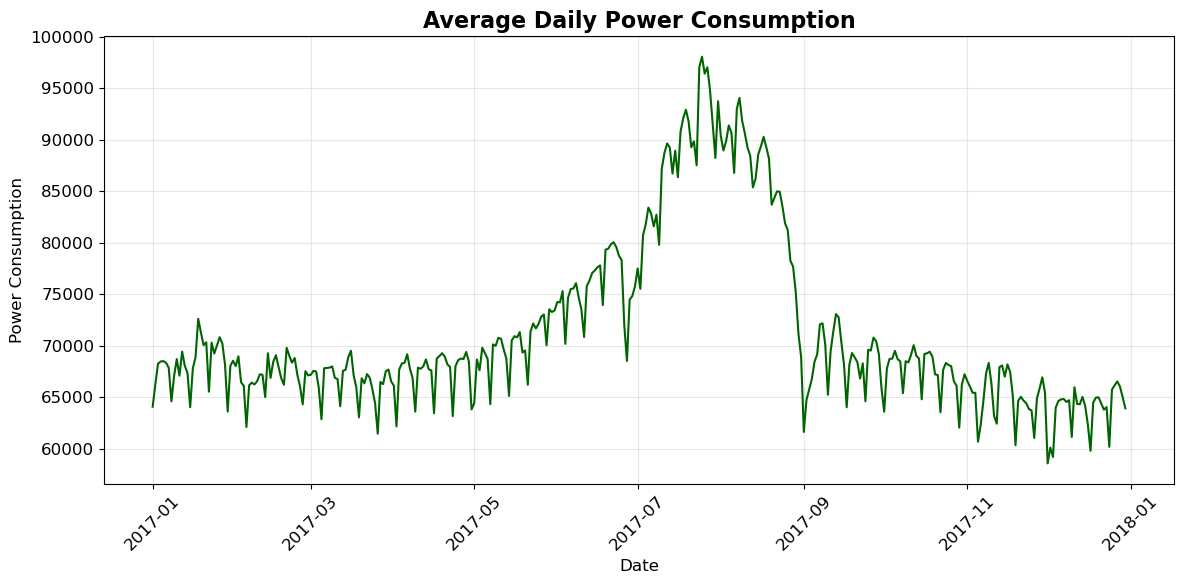


Observation: The average daily power consumption shows an overall trend that peaks in the summer months
and potentially a weekly seasonal trend. The data is not stationary and the variance seems to be constant
disregarding the overall trend.


In [18]:
# Create a copy of the dataframe for plotting
plot_df = powerconsumption.copy()

# Create daily average consumption data in the copied dataframe
plot_df['date'] = plot_df.index.date
avg_daily = plot_df.groupby('date')['total_consumption'].mean().reset_index()
avg_daily.columns = ['date', 'avg_daily_consumption']

print("Daily average consumption data:")
print(avg_daily.head())

# Convert date back to datetime for plotting
avg_daily['date'] = pd.to_datetime(avg_daily['date'])

# Plot average daily power consumption
plt.figure(figsize=(12, 6))
plt.plot(avg_daily['date'], avg_daily['avg_daily_consumption'], color='darkgreen', linewidth=1.5)
plt.title('Average Daily Power Consumption', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Power Consumption', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nObservation: The average daily power consumption shows an overall trend that peaks in the summer months")
print("and potentially a weekly seasonal trend. The data is not stationary and the variance seems to be constant")
print("disregarding the overall trend.")


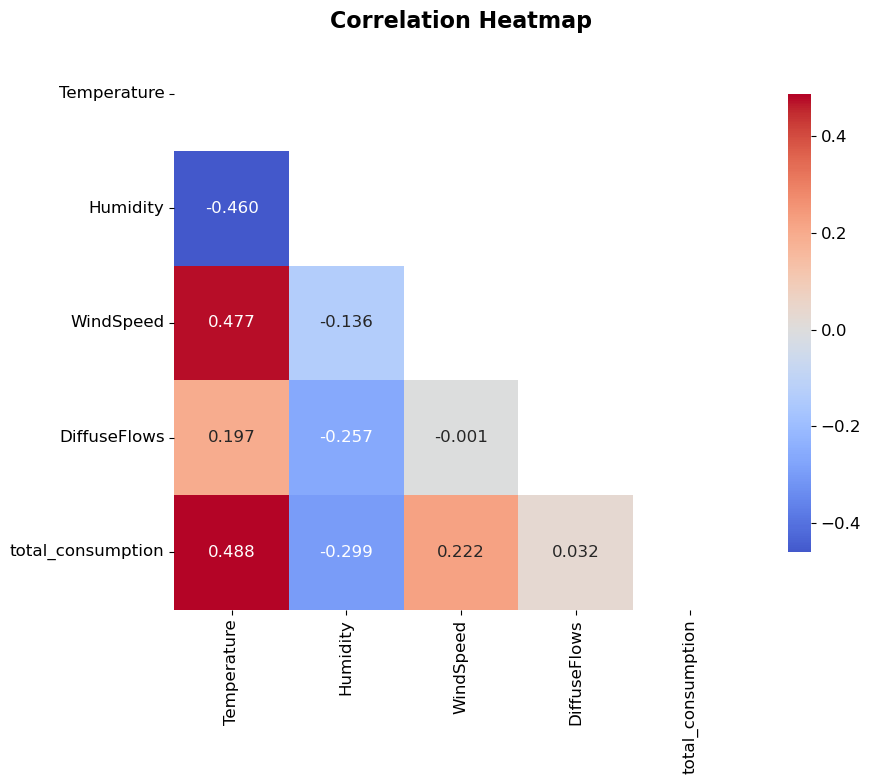

Correlation Matrix:
                   Temperature  Humidity  WindSpeed  DiffuseFlows  \
Temperature              1.000    -0.460      0.477         0.197   
Humidity                -0.460     1.000     -0.136        -0.257   
WindSpeed                0.477    -0.136      1.000        -0.001   
DiffuseFlows             0.197    -0.257     -0.001         1.000   
total_consumption        0.488    -0.299      0.222         0.032   

                   total_consumption  
Temperature                    0.488  
Humidity                      -0.299  
WindSpeed                      0.222  
DiffuseFlows                   0.032  
total_consumption              1.000  

Observation: The Temperature variable seems to be moderately correlated to Humidity,
WindSpeed, and total_consumption.


In [19]:
# Create correlation matrix for relevant variables
corr_variables = ['Temperature', 'Humidity', 'WindSpeed', 'DiffuseFlows', 'total_consumption']
corr_matrix = powerconsumption[corr_variables].corr()

# Create correlation heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Create mask for upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f', cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation Matrix:")
print(corr_matrix.round(3))
print("\nObservation: The Temperature variable seems to be moderately correlated to Humidity,")
print("WindSpeed, and total_consumption.")


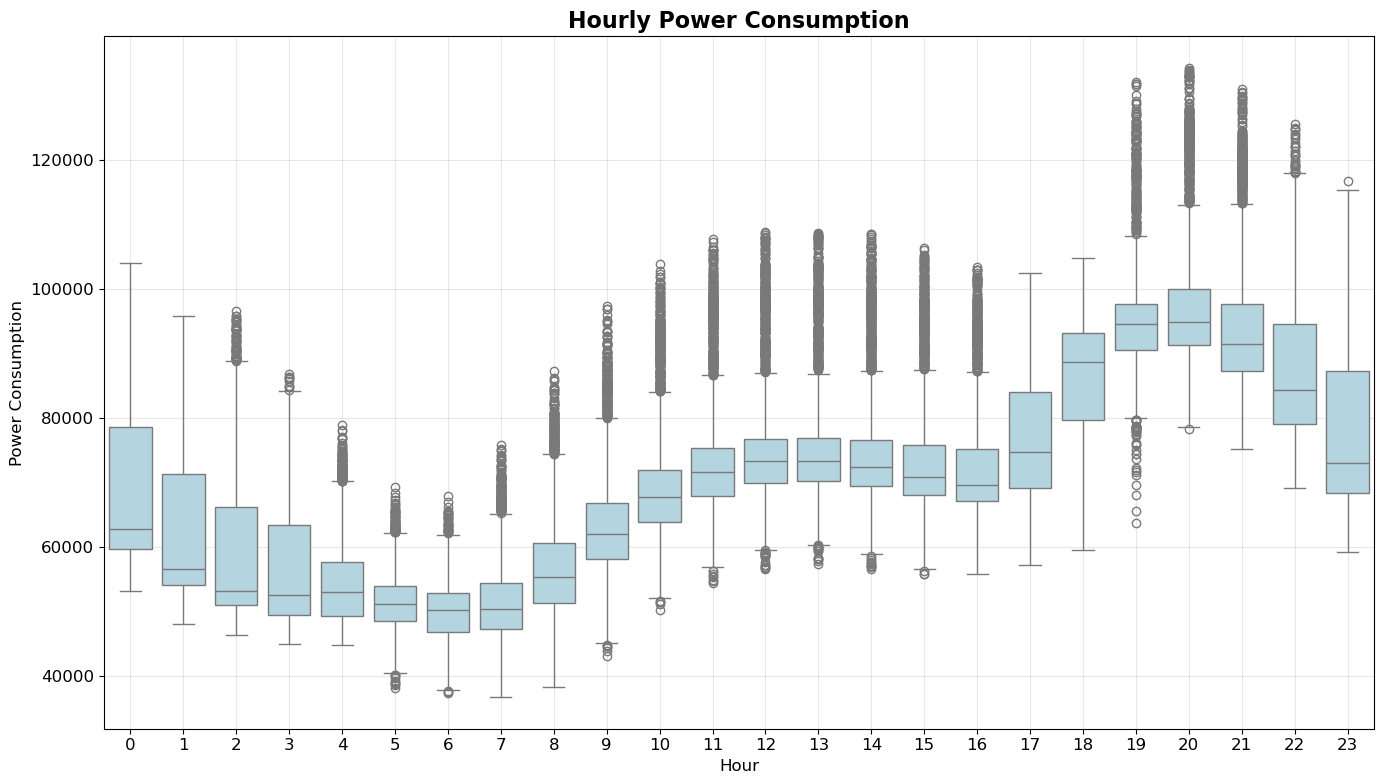

Observation: There is potentially a seasonal trend across the hours of the day.
Lowest consumption is around 6am and increases until about 8pm where it begins to decrease again.


In [20]:
# Extract hour from datetime for hourly analysis in a copy of the dataframe
powerconsumption_hourly = powerconsumption.copy()
powerconsumption_hourly['hour'] = powerconsumption_hourly.index.hour

# Create hourly power consumption boxplot
plt.figure(figsize=(14, 8))
sns.boxplot(data=powerconsumption_hourly, x='hour', y='total_consumption', color='lightblue')
plt.title('Hourly Power Consumption', fontsize=16, fontweight='bold')
plt.xlabel('Hour', fontsize=12)
plt.ylabel('Power Consumption', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Observation: There is potentially a seasonal trend across the hours of the day.")
print("Lowest consumption is around 6am and increases until about 8pm where it begins to decrease again.")


In [12]:
# Summary statistics
print("=== SUMMARY STATISTICS ===")
print("\nDataset Information:")
print(f"Time period: {powerconsumption.index.min()} to {powerconsumption.index.max()}")
print(f"Total number of observations: {len(powerconsumption)}")
print(f"Measurement frequency: Every 10 minutes")

print(f"\nDescriptive Statistics for Key Variables:")
summary_stats = powerconsumption[['Temperature', 'Humidity', 'WindSpeed', 'DiffuseFlows', 'total_consumption']].describe()
print(summary_stats.round(2))

# Check for missing values
print(f"\nMissing Values:")
missing_values = powerconsumption.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found")


=== SUMMARY STATISTICS ===

Dataset Information:
Time period: 2017-01-01 00:00:00 to 2017-12-30 23:50:00
Total number of observations: 52416
Measurement frequency: Every 10 minutes

Descriptive Statistics for Key Variables:
       Temperature  Humidity  WindSpeed  DiffuseFlows  total_consumption
count     52416.00  52416.00   52416.00      52416.00           52416.00
mean         18.81     68.26       1.96         75.03           71222.89
std           5.82     15.55       2.35        124.21           17143.14
min           3.25     11.34       0.05          0.01           36785.04
25%          14.41     58.31       0.08          0.12           56499.07
50%          18.78     69.86       0.09          4.46           69788.79
75%          22.89     81.40       4.92        101.00           83749.17
max          40.01     94.80       6.48        936.00          134208.15

Missing Values:
No missing values found


In [22]:
def engineer_features(df, target_col):
    """
    Create comprehensive time-series features
    
    Args:
        df: DataFrame with time series data
        target_col: Target column to engineer features for
        
    Returns:
        DataFrame with engineered features
    """
    # Create a copy to avoid modifying original data
    df_features = df.copy()

    # 1. LAG FEATURES
    # These capture autocorrelation - how past values predict future values

    lags = [144,288]  
    for lag in lags:
        # Target variable lags
        df_features[f'{target_col}_lag_{lag}'] = df_features[target_col].shift(lag)
        
    
    # 2. ROLLING STATISTICS
    # These capture trends and smoothed patterns

    windows = [144,288]
    
    for window in windows:
        # Rolling mean (trend)
        df_features[f'{target_col}_rolling_mean_{window}'] = df_features[target_col].rolling(window=window).mean()
        
        # Rolling std (volatility)
        df_features[f'{target_col}_rolling_std_{window}'] = df_features[target_col].rolling(window=window).std()
        
        # Rolling min/max (range)
        df_features[f'{target_col}_rolling_min_{window}'] = df_features[target_col].rolling(window=window).min()
        df_features[f'{target_col}_rolling_max_{window}'] = df_features[target_col].rolling(window=window).max()
    
    # 3. TEMPORAL FEATURES
    # These capture seasonality and calendar effects

    # Extract basic temporal components
    df_features['hour'] = df_features.index.hour
    df_features['month'] = df_features.index.month
    df_features['quarter'] = df_features.index.quarter
    # Add is_weekend feature: 1 if Saturday or Sunday, else 0
    df_features['is_weekend'] = df_features.index.weekday.isin([5, 6]).astype(int)
    #df_features['year'] = df_features.index.year

    # Cyclical encoding for seasonal patterns
    df_features['hour_cos'] = np.cos(2 * np.pi * df_features['hour'] / 24)

    # Drop low importance features
    #df_features = df_features.drop(columns=['hour'])

    
    
    df_features = df_features.dropna()
    
    return df_features

In [23]:
# Data Preparation for XGBoost Training

def prepare_data_for_training(df, split_date, target_col):
    """
    Prepare time-series data for XGBoost training with proper temporal splits.
    
    Args:
        df: input dataframe
        split_date: date to split the data into train and test
     
    Returns:
        Tuple of (X_train, X_test, y_train, y_test, feature_names)
    """
    
    # Remove rows with missing values from lags
    df_clean = df.dropna()
    
    # # Check for any remaining missing values
    # missing_count = df_clean.isnull().sum()
    # if missing_count > 0:
    #     print(f"⚠️ Warning: {missing_count} missing values remain after filling")
    # else:
    #     print("✅ No missing values in feature set")
    
    # Time-aware train/test split (crucial for time series!)
    train = df_clean.loc[df_clean.index < split_date]
    test = df_clean.loc[df_clean.index >= split_date]

    train = engineer_features(train, target_col)
    test = engineer_features(test, target_col)

    X_train = train.drop(target_col, axis=1)
    X_test = test.drop(target_col, axis=1)
    y_train = train[target_col]
    y_test = test[target_col]        


    print(f"🏋️ Training set: {len(X_train)} samples")
    print(f"🧪 Test set: {len(X_test)} samples")
    print(f"📊 Number of features: {len(X_train.columns)}")
    
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = prepare_data_for_training(powerconsumption, '2017-12-01', 'total_consumption')
feature_names = X_train.columns.tolist()
# # Display feature information
print("\n🔍 Feature Overview:")
print(f"Feature count by category:")
lag_features = [f for f in feature_names if 'lag' in f]
rolling_features = [f for f in feature_names if 'rolling' in f]
temporal_features = [f for f in feature_names if any(x in f for x in ['year', 'month', 'day', 'weekend', 'sin', 'cos'])]
other_features = [f for f in feature_names if f not in lag_features + rolling_features + temporal_features]

print(f"  • Lag features: {len(lag_features)}")
print(f"  • Rolling statistics: {len(rolling_features)}")
print(f"  • Temporal features: {len(temporal_features)}")
print(f"  • Other features: {len(other_features)}")

# Show sample of each category
print(f"\n📋 Sample features:")
print(f"  • Lag: {lag_features[:3]}")
print(f"  • Rolling: {rolling_features[:3]}")
print(f"  • Temporal: {temporal_features[:3]}")
print(f"  • Other: {other_features[:3]}")

print(X_train.tail())
print(X_test.head())

🏋️ Training set: 47808 samples
🧪 Test set: 4032 samples
📊 Number of features: 20

🔍 Feature Overview:
Feature count by category:
  • Lag features: 2
  • Rolling statistics: 8
  • Temporal features: 3
  • Other features: 7

📋 Sample features:
  • Lag: ['total_consumption_lag_144', 'total_consumption_lag_288']
  • Rolling: ['total_consumption_rolling_mean_144', 'total_consumption_rolling_std_144', 'total_consumption_rolling_min_144']
  • Temporal: ['month', 'is_weekend', 'hour_cos']
  • Other: ['Temperature', 'Humidity', 'WindSpeed']
                     Temperature  Humidity  WindSpeed  GeneralDiffuseFlows  \
Datetime                                                                     
2017-11-30 23:10:00        12.65      85.9      0.074                0.051   
2017-11-30 23:20:00        12.62      86.1      0.071                0.069   
2017-11-30 23:30:00        12.63      86.2      0.071                0.066   
2017-11-30 23:40:00        12.56      86.1      0.071                0.0

In [26]:
# Feature Selection
rfe_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.1,
    random_state=3
)
tscv = TimeSeriesSplit(n_splits=5)
rfecv = RFECV(
    estimator=rfe_model,
    step=1,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    min_features_to_select=1,
    n_jobs=-1  # Parallelize if possible to speed up
)
rfecv.fit(X_train, y_train)
selected_features = X_train.columns[rfecv.support_]
print(f"Optimal number of features: {rfecv.n_features_}")
print(f"Selected features: {list(selected_features)}")
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

Optimal number of features: 6
Selected features: ['GeneralDiffuseFlows', 'total_consumption_lag_144', 'total_consumption_lag_288', 'total_consumption_rolling_min_144', 'hour', 'is_weekend']


In [27]:
# Grid Search for XGBoost
param_grid = {
    'n_estimators': [3000],
    'max_depth': [2,3],
    'learning_rate': [0.01, 0.05],
    'reg_alpha': [0,0.5],
    'reg_lambda': [0,1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}
tscv = TimeSeriesSplit(n_splits=5)
xgb_model = xgb.XGBRegressor( 
    random_state=3,
)

grid_cv = GridSearchCV(xgb_model, param_grid, 
                      cv=tscv, scoring='neg_root_mean_squared_error')
grid_cv.fit(X_train_selected, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8], 'learning_rate': [0.01, 0.05], 'max_depth': [2, 3], 'n_estimators': [3000], ...}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [28]:
best_model = grid_cv.best_estimator_
y_train_pred = best_model.predict(X_train_selected)
y_test_pred = best_model.predict(X_test_selected)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_test_gap = abs((test_rmse - train_rmse)/train_rmse)

print("\n📊 GridSearchCV Best Model Performance:")
print(f"  Training RMSE: {train_rmse:.3f}")
print(f"  Test RMSE: {test_rmse:.3f}")
print(f"  Training MAE: {train_mae:.3f}")
print(f"  Test MAE: {test_mae:.3f}")
print(f"  Train Test Gap %: {train_test_gap*100:.3f}%")

print("\n🏆 Best Model Parameters (GridSearchCV):")
print(grid_cv.best_params_)



📊 GridSearchCV Best Model Performance:
  Training RMSE: 2375.724
  Test RMSE: 2132.018
  Training MAE: 1727.057
  Test MAE: 1625.072
  Train Test Gap %: 10.258%

🏆 Best Model Parameters (GridSearchCV):
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 3000, 'reg_alpha': 0.5, 'reg_lambda': 0, 'subsample': 0.8}


🚀 Training XGBoost Model
🔧 Final Model Parameters:
  • colsample_bytree: 0.8
  • learning_rate: 0.01
  • max_depth: 2
  • n_estimators: 4000
  • reg_alpha: 0.5
  • reg_lambda: 0
  • subsample: 0.8
  • eval_metric: rmse
  • random_state: 3
  • early_stopping_rounds: 50

🏋️ Training in progress...
[0]	validation_0-rmse:17067.07880	validation_1-rmse:16199.75080
[500]	validation_0-rmse:2914.33581	validation_1-rmse:2461.24387
[1000]	validation_0-rmse:2692.51171	validation_1-rmse:2280.51517
[1500]	validation_0-rmse:2585.27604	validation_1-rmse:2232.81007
[2000]	validation_0-rmse:2506.34698	validation_1-rmse:2196.04974
[2500]	validation_0-rmse:2432.52699	validation_1-rmse:2163.31542
[3000]	validation_0-rmse:2375.59896	validation_1-rmse:2131.88872
[3500]	validation_0-rmse:2329.59864	validation_1-rmse:2110.53835
[3624]	validation_0-rmse:2320.36664	validation_1-rmse:2109.33389

📊 Model Performance:
  Training RMSE: 2323.954
  Test RMSE: 2108.794
  Training MAE: 1688.462
  Test MAE: 1602.974
  Tr

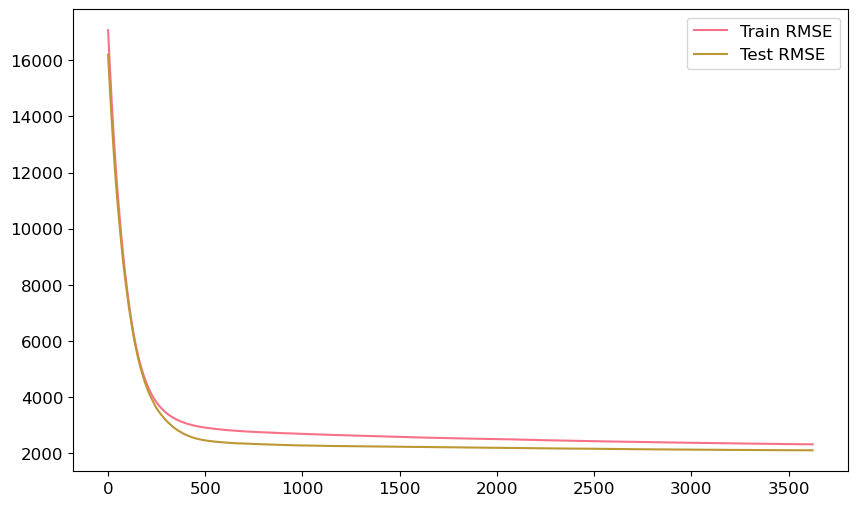

In [31]:
# XGBoost Model Training with Time-Series Cross-Validation

def train_xgboost_model(X_train, y_train, X_test, y_test):
    """
    Train XGBoost model with time-series specific considerations.
    
    Statistical Context: Uses gradient boosting with regularization for robust predictions
    Engineering Context: Implements production-ready model training pipeline
    MLOps Context: Includes validation and performance metrics for monitoring
    
    Returns:
        Trained model and performance metrics
    """
    print("🚀 Training XGBoost Model")
    print("=" * 40)
    
    # # XGBoost parameters optimized for time-series forecasting
    # xgb_params = { 
    #     'eval_metric': 'rmse',            
    #     'max_depth': 3,                    
    #     'learning_rate': 0.01,              
    #     'n_estimators': 4000,                
    #     'subsample': 0.8, # Sample ratio of training instances
    #     'colsample_bytree': 0.8, # Sample ratio of features
    #     'reg_alpha': 0.5, # L1 regularization
    #     'reg_lambda': 1, # L2 regularization
    #     'random_state': 3,                
    #     'early_stopping_rounds': 50,       
    # }
    final_params = grid_cv.best_params_
    final_params.update({'eval_metric': 'rmse',
                         'random_state': 3,
                         'early_stopping_rounds': 50,
                         'n_estimators': 4000,
                         })
    
    print("🔧 Final Model Parameters:")
    for key, value in final_params.items():
        print(f"  • {key}: {value}")
    
    # Create and train the model
    model = xgb.XGBRegressor(**final_params)


    # Fit model with validation set for early stopping
    print("\n🏋️ Training in progress...")
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=500
    )

    # Make predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Calculate performance metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    train_test_gap = abs((test_rmse - train_rmse)/train_rmse)
    
    print("\n📊 Model Performance:")
    print(f"  Training RMSE: {train_rmse:.3f}")
    print(f"  Test RMSE: {test_rmse:.3f}")
    print(f"  Training MAE: {train_mae:.3f}")
    print(f"  Test MAE: {test_mae:.3f}")
    print(f"  Train Test Gap %: {train_test_gap*100:.3f}%")

    
    # Check for overfitting
    if train_test_gap > 0.5:
        print("⚠️ Potential overfitting detected (train RMSE much lower than test RMSE)")
    else:
        print("✅ Model shows good generalization")
    
    return model, {
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae


    }

# Train the model
model, metrics = train_xgboost_model(X_train_selected, y_train, X_test_selected, y_test)

results = model.evals_result()
plt.plot(results['validation_0']['rmse'], label='Train RMSE')
plt.plot(results['validation_1']['rmse'], label='Test RMSE')
plt.legend()
plt.show()

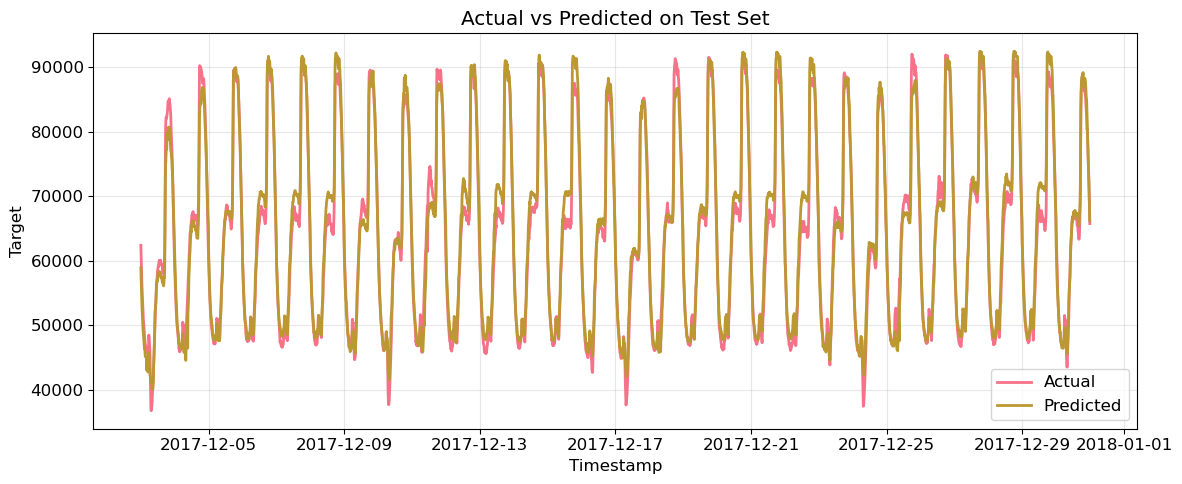

In [36]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label='Actual', linewidth=2)
plt.plot(y_test.index, y_test_pred, label='Predicted', linewidth=2)
plt.title('Actual vs Predicted on Test Set')
plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

🔍 Feature Importance:
0.5868 - total_consumption_lag_144
0.3515 - total_consumption_lag_288
0.0367 - hour
0.0119 - is_weekend
0.0104 - total_consumption_rolling_min_144
0.0027 - GeneralDiffuseFlows


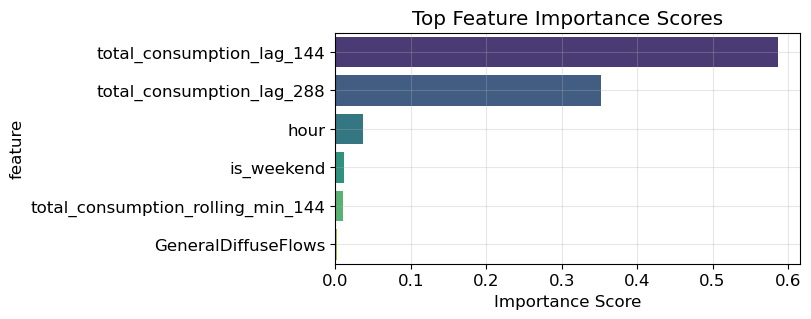


📊 Feature Importance by Category:
----------------------------------------
🔄 Lag Features: 0.938 (93.8%)
📊 Rolling/Statistical Features: 0.010 (1.0%)
📅 Temporal Features: 0.049 (4.9%)
🌦️ Weather Features: 0.003 (0.3%)


In [39]:
# Feature Importance Analysis
# This is crucial for understanding what drives our predictions

def analyze_feature_importance(model):
    """
    Analyze and visualize feature importance from XGBoost model.

    
    Args:
        model: Trained XGBoost model
    """
    # Get feature importance scores
    importance_scores = model.feature_importances_
    
    # Create feature importance dataframe
    feature_importance_df = pd.DataFrame({
        'feature': model.get_booster().feature_names,
        'importance': importance_scores
    }).sort_values('importance', ascending=False)
    
    print(f"🔍 Feature Importance:")
    print("=" * 50)
    
    # Display top features with interpretation
    top_features = feature_importance_df
    for idx, row in top_features.iterrows():
        print(f"{row['importance']:.4f} - {row['feature']}")
    
    # Visualization
    plt.figure(figsize=(6, 3))
    
    # Top features bar plot

    sns.barplot(data=top_features, x='importance', y='feature', palette='viridis')
    plt.title(f'Top Feature Importance Scores')
    plt.xlabel('Importance Score')
    plt.grid(True, alpha=0.3)
    
    plt.show()
    
    # Analyze feature categories for the best model's features
    print("\n📊 Feature Importance by Category:")
    print("-" * 40)

    # Define feature categories based on the best model's features
    # Adjust these patterns to match your actual feature engineering
    lag_mask = top_features['feature'].str.contains('lag', case=False)
    rolling_mask = top_features['feature'].str.contains('rolling|mean|std|ewm', case=False)
    temporal_mask = top_features['feature'].str.contains('month|day|hour|minute|week|weekday|weekend|sin|cos', case=False)
    weather_mask = top_features['feature'].str.contains('temperature|humidity|windspeed|diffuse|flow', case=False)
    # If you have other engineered features, add more masks as needed

    lag_importance = top_features[lag_mask]['importance'].sum()
    rolling_importance = top_features[rolling_mask]['importance'].sum()
    temporal_importance = top_features[temporal_mask]['importance'].sum()
    weather_importance = top_features[weather_mask]['importance'].sum()

    total_importance = top_features['importance'].sum()

    print(f"🔄 Lag Features: {lag_importance:.3f} ({lag_importance/total_importance*100:.1f}%)")
    print(f"📊 Rolling/Statistical Features: {rolling_importance:.3f} ({rolling_importance/total_importance*100:.1f}%)")
    print(f"📅 Temporal Features: {temporal_importance:.3f} ({temporal_importance/total_importance*100:.1f}%)")
    print(f"🌦️ Weather Features: {weather_importance:.3f} ({weather_importance/total_importance*100:.1f}%)")
    return feature_importance_df

# Analyze feature importance
feature_importance_df = analyze_feature_importance(model)